## Vanna AI — StarScemaSPARS (DataLens)

This notebook uses **StarScemaSPARS** on `192.168.1.249\sparsweb` with the same credentials as the DataLens backend (`.env`). It trains on the star-schema views and business documentation for robust, accurate SQL generation.

In [2]:
# Use backend root for .env and imports (run from backend folder, or notebook in db_resources)
import os
import sys
cwd = os.getcwd()
backend_root = cwd if "db_resources" not in cwd else os.path.abspath(os.path.join(cwd, ".."))
if backend_root not in sys.path:
    sys.path.insert(0, backend_root)
os.chdir(backend_root)

try:
    from dotenv import load_dotenv
    load_dotenv(os.path.join(backend_root, ".env"))
except Exception:
    pass

from vanna.openai import OpenAI_Chat
from vanna.chromadb import ChromaDB_VectorStore


In [ ]:
os.environ["CHROMA_TELEMETRY_ENABLED"] = "false"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

class MyVanna(ChromaDB_VectorStore, OpenAI_Chat):
    def __init__(self, config=None):
        config = config or {}
        ChromaDB_VectorStore.__init__(self, config=config)
        OpenAI_Chat.__init__(self, config=config)

# Use OPENAI_API_KEY from .env; ChromaDB under backend/vanna_chromadb
api_key = os.getenv("OPENAI_API_KEY", "")
vn = MyVanna(config={
    "api_key": api_key,
    "model": "gpt-4o-mini",
    "path": os.path.join(backend_root, "vanna_chromadb"),
})
print("Vanna initialized (OpenAI + ChromaDB)")


In [4]:
# StarScemaSPARS — same as DataLens .env
SERVER = os.getenv("SQL_SERVER", "192.168.1.249\\sparsweb")
DATABASE = os.getenv("SQL_DATABASE", "StarScemaSPARS")
USER = os.getenv("SQL_USER", "DEVUser")
PASSWORD = os.getenv("SQL_PASSWORD", "DEVUser")
DRIVER = os.getenv("SQL_DRIVER", "ODBC Driver 17 for SQL Server")

odbc_str = (
    f"DRIVER={{{DRIVER}}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"UID={USER};"
    f"PWD={PASSWORD};"
    "TrustServerCertificate=yes;"
    "Encrypt=no;"
)
vn.connect_to_mssql(odbc_conn_str=odbc_str)
print(f"Connected to {SERVER} / {DATABASE}")


## Training (Star schema views + business docs)

Train on the 6 pre-built views and shared business documentation. Run once; same knowledge is used by the DataLens backend (LangChain and Vanna agents).

In [15]:
# Train on StarScemaSPARS views and business docs (same as backend db_knowledge)
from app.services.db_knowledge import get_training_docs, ALL_VIEW_DDLS

for i, ddl in enumerate(ALL_VIEW_DDLS):
    vn.train(ddl=ddl.strip())
    print(f"Trained view DDL {i+1}/{len(ALL_VIEW_DDLS)}")
vn.train(documentation=get_training_docs())
print("Training complete (views + documentation).")


Train on Information Schema: SPARS_DW.dbo DW_SALE
Train on Information Schema: SPARS_DW.dbo DS_Consolidate
Train on Information Schema: SPARS_DW.dbo DW_SDET
Train on Information Schema: SPARS_DW.dbo DS_CrossTabBy
Train on Information Schema: SPARS_DW.dbo CM_Consolidate
Train on Information Schema: SPARS_DW.dbo sysdiagrams
Train on Information Schema: SPARS_DW.dbo Vendors
Train on Information Schema: SPARS_DW.dbo GenericSizes
Train on Information Schema: SPARS_DW.dbo message_store
Train on Information Schema: SPARS_DW.dbo zdt_DW_SALE_bkup_20Oct2025
Train on Information Schema: SPARS_DW.dbo zdt_DW_SDET_bkup_20Oct2025
Train on Information Schema: SPARS_DW.dbo TMP_Cust_SR
Train on Information Schema: SPARS_DW.dbo Category
Train on Information Schema: SPARS_DW.dbo Region
Train on Information Schema: SPARS_DW.dbo DW_PMTS
Train on Information Schema: SPARS_DW.dbo DW_COMM
Train on Information Schema: SPARS_DW.dbo DW_CMDT
Train on Information Schema: SPARS_DW.dbo DW_SP_Para

In [26]:
# Optional: inspect training data
# vn.get_training_data()

# Sample: generate SQL for a natural language question
question = "What is the yearly sales summary? Show total sales amount and number of invoices by year."
sql = vn.generate_sql(question)
print("Generated SQL:")
print(sql)
df = vn.run_sql(sql)
df


🔍 Fetching Tables info...
🔍 Fetching Columns info...
🔍 Fetching Keys info...
🔍 Fetching Indexes info...
🔍 Fetching ForeignKeys info...
Adding ddl: 

-- Tables --
TABLE_SCHEMA                 TABLE_NAME
         dbo                   Category
         dbo             CM_Consolidate
         dbo             DS_Consolidate
         dbo              DS_CrossTabBy
         dbo                    DW_CMDT
         dbo                    DW_COMM
         dbo                    DW_PMTS
         dbo                    DW_SALE
         dbo                    DW_SDET
         dbo                 DW_SP_Para
         dbo               GenericSizes
         dbo              message_store
         dbo                     Region
         dbo                sysdiagrams
         dbo                TMP_Cust_SR
         dbo                    Vendors
         dbo zdt_DW_SALE_bkup_20Oct2025
         dbo zdt_DW_SDET_bkup_20Oct2025

-- Columns --
TABLE_SCHEMA                 TABLE_NAME       COLUMN_NAME DATA_

'ddf75eb2-b006-5185-8a27-1662a5572bac-doc'

In [27]:
# At any time you can inspect what training data the package is able to reference
training_data = vn.get_training_data()
training_data

,id,question,content,training_data_type
0,959d3b6f-f931-5af5-a730-0c9b018a2c73-sql,How many tables are in the database,SELECT COUNT(*) AS TableCount\nFROM INFORMATIO...,sql
1,4f5f4195-a61e-5ef6-a563-a2085e983638-sql,what are the column names of the table name VE...,SELECT COLUMN_NAME\nFROM INFORMATION_SCHEMA.CO...,sql
2,3ecddf16-14e9-5046-99d5-2260e08fe4d4-sql,how many invoices were generated in 2024,SELECT COUNT(*) AS InvoiceCount\nFROM dbo.DW_C...,sql
0,f8e1cb6a-3b0d-5304-b4ce-5a8e3357220a-ddl,None,\n\n-- Tables --\nTABLE_SCHEMA ...,ddl
0,ddf75eb2-b006-5185-8a27-1662a5572bac-doc,None,Below are the tables info and other tables are...,documentation


In [ ]:
# You can remove training data if there's obsolete/incorrect information.
vn.remove_training_data(id='1-ddl')


## Asking the AI
Whenever you ask a new question, it will find the 10 most relevant pieces of training data and use it as part of the LLM prompt to generate the SQL.

SQL Prompt: [{'role': 'system', 'content': 'You are a T-SQL / Microsoft SQL Server expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \n\n\n-- Tables --\nTABLE_SCHEMA                 TABLE_NAME\n         dbo                   Category\n         dbo             CM_Consolidate\n         dbo             DS_Consolidate\n         dbo              DS_CrossTabBy\n         dbo                    DW_CMDT\n         dbo                    DW_COMM\n         dbo                    DW_PMTS\n         dbo                    DW_SALE\n         dbo                    DW_SDET\n         dbo                 DW_SP_Para\n         dbo               GenericSizes\n         dbo              message_store\n         dbo                     Region\n         dbo                sysdiagrams\n         dbo                TMP_Cust_SR\n         dbo                    Vendors\n    

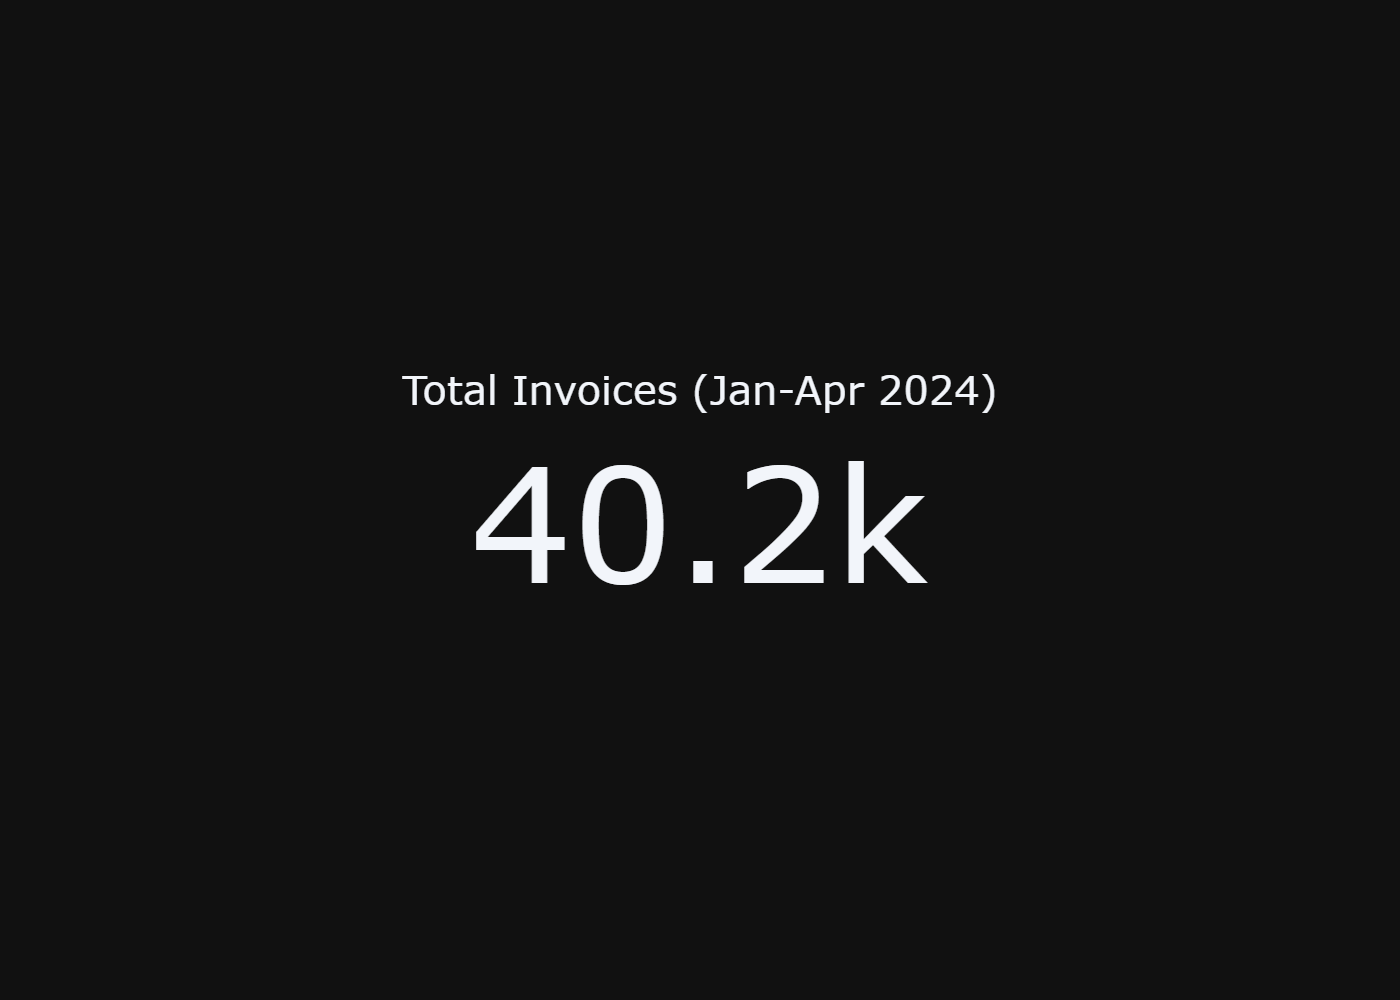

("SELECT COUNT(*) AS TotalInvoiceCount\nFROM dbo.DW_SALE\nWHERE YYYY = '2024'\n  AND MM BETWEEN 1 AND 4\n  AND Type = 'S';",
    TotalInvoiceCount
 0              40207,
 Figure({
     'data': [{'mode': 'number', 'title': {'text': 'Total Invoices (Jan-Apr 2024)'}, 'type': 'indicator', 'value': 40207}],
     'layout': {'template': '...'}
 }))

In [6]:

vn.ask(question=f"""Below are the tables info and other tables are not mentioned bcz they are related to them already. use them to take better insights.
            DW_SALE = Header of the Sales Invoice like customers info, customer purchase order info, shipping info.
            DW_SDET = Details of the Sales Invoice like items info, QTY info, pricing info for individual lines.
            DW_COMM = Details of agents or Commission representative info, commission against each agent, number of agents.
            
            -> Types in DW_SALE

(HELPFUL FOR FILTERING THE INVOICES BASED ON USER KEYWORDS)
IF Type = S and SubType = O
THEN 
One Step Invoice
 
IF Type = S and SubType = S
THEN
Sales Invoice, Invoices, Sales
 
IF Type = D
THEN 
Customer Debit, Debit Memo, Debit Memos
 
IF Type = M
THEN
Credit Memo, Credit Memos, One Step Credit
 
IF Type = C
THEN
Customer Credit

So above info is being used as below: 

And if i'm using the keyword "Sales" in my query then it should collect the data that include Type = S only.
And if i'm using the keyword "Credit" in my query then it should collect the data that include Type = C,M both.
And if i'm using the keyword "Debit" in my query then it should collect the data that include Type = D only.
And if i'm using the keyword "Credits with merchandise" in my query then it should collect the data that include Type = M only.
 
NOTE**: These types and sub types information is only for helpful to understand the tables' data better but never include these types and subtype in the response, (e.g, in the table)
            ** You are only required to execute the read only queries.
            Understanding Context:
            how many total invoices were generated in first 4 months of 2024""",allow_llm_to_see_data=True)